In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_excel("../dataset/Data_Train.xlsx")
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [48]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape: (6019, 13)

Column Names:
Index(['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'New_Price', 'Price'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   str    
 1   Location           6019 non-null   str    
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   str    
 5   Transmission       6019 non-null   str    
 6   Owner_Type         6019 non-null   str    
 7   Mileage            6017 non-null   str    
 8   Engine             5983 non-null   str    
 9   Power              5983 non-null   str    
 10  Seats              5977 non-null   float64
 11  New_Price         

In [49]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  42
New_Price            5195
Price                   0
dtype: int64

Duplicate Rows: 0


In [50]:
# Remove New_Price column because it has too many missing values
df.drop(columns=['New_Price'], inplace=True)

# Fill missing values
df['Mileage'] = df['Mileage'].fillna(df['Mileage'].mode()[0])
df['Engine'] = df['Engine'].fillna(df['Engine'].mode()[0])
df['Power'] = df['Power'].fillna(df['Power'].mode()[0])
df['Seats'] = df['Seats'].fillna(df['Seats'].median())

# Check missing values again
print("Missing Values After Cleaning:")
print(df.isnull().sum())

# Display dataset shape
print("\nDataset Shape:", df.shape)

Missing Values After Cleaning:
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

Dataset Shape: (6019, 12)


In [51]:
# Convert Mileage, Engine and Power into numerical values

df['Mileage'] = df['Mileage'].str.extract(r'(\d+\.?\d*)').astype(float)

df['Engine'] = df['Engine'].str.extract(r'(\d+\.?\d*)').astype(float)

df['Power'] = df['Power'].str.extract(r'(\d+\.?\d*)').astype(float)

# Check the data types
print(df.dtypes)

# Display first 5 rows
df.head()

Name                     str
Location                 str
Year                   int64
Kilometers_Driven      int64
Fuel_Type                str
Transmission             str
Owner_Type               str
Mileage              float64
Engine               float64
Power                float64
Seats                float64
Price                float64
dtype: object


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,17.74


In [52]:
#Feature Engineering
# Create Car Age feature
df['Car_Age'] = 2026 - df['Year']

# Extract Brand from the Name column
df['Brand'] = df['Name'].str.split().str[0]

# Display important columns
print(df[['Name', 'Brand', 'Year', 'Car_Age', 'Price']].head())

# Check number of unique brands
print("\nNumber of Brands:", df['Brand'].nunique())

print("\nBrands:")
print(df['Brand'].unique())

                               Name    Brand  Year  Car_Age  Price
0            Maruti Wagon R LXI CNG   Maruti  2010       16   1.75
1  Hyundai Creta 1.6 CRDi SX Option  Hyundai  2015       11  12.50
2                      Honda Jazz V    Honda  2011       15   4.50
3                 Maruti Ertiga VDI   Maruti  2012       14   6.00
4   Audi A4 New 2.0 TDI Multitronic     Audi  2013       13  17.74

Number of Brands: 31

Brands:
['Maruti' 'Hyundai' 'Honda' 'Audi' 'Nissan' 'Toyota' 'Volkswagen' 'Tata'
 'Land' 'Mitsubishi' 'Renault' 'Mercedes-Benz' 'BMW' 'Mahindra' 'Ford'
 'Porsche' 'Datsun' 'Jaguar' 'Volvo' 'Chevrolet' 'Skoda' 'Mini' 'Fiat'
 'Jeep' 'Smart' 'Ambassador' 'Isuzu' 'ISUZU' 'Force' 'Bentley'
 'Lamborghini']


In [53]:
# Basic statistics of car prices
print(df['Price'].describe())

# Check most expensive and cheapest cars
print("\nCheapest Car:")
print(df.loc[df['Price'].idxmin(), ['Name', 'Price']])

print("\nMost Expensive Car:")
print(df.loc[df['Price'].idxmax(), ['Name', 'Price']])

count    6019.000000
mean        9.479468
std        11.187917
min         0.440000
25%         3.500000
50%         5.640000
75%         9.950000
max       160.000000
Name: Price, dtype: float64

Cheapest Car:
Name     Tata Nano Lx
Price            0.44
Name: 1713, dtype: object

Most Expensive Car:
Name     Land Rover Range Rover 3.0 Diesel LWB Vogue
Price                                          160.0
Name: 4079, dtype: object


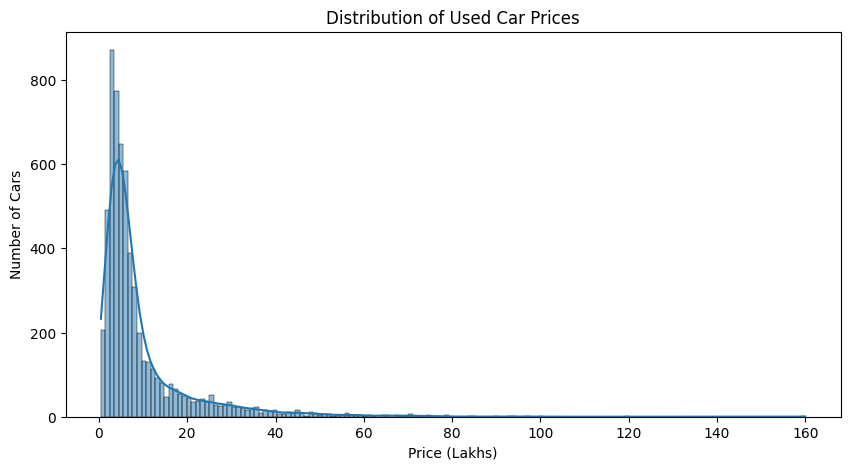

In [54]:
# Distribution of car prices

plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], kde=True)

plt.title('Distribution of Used Car Prices')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Number of Cars')

plt.show()

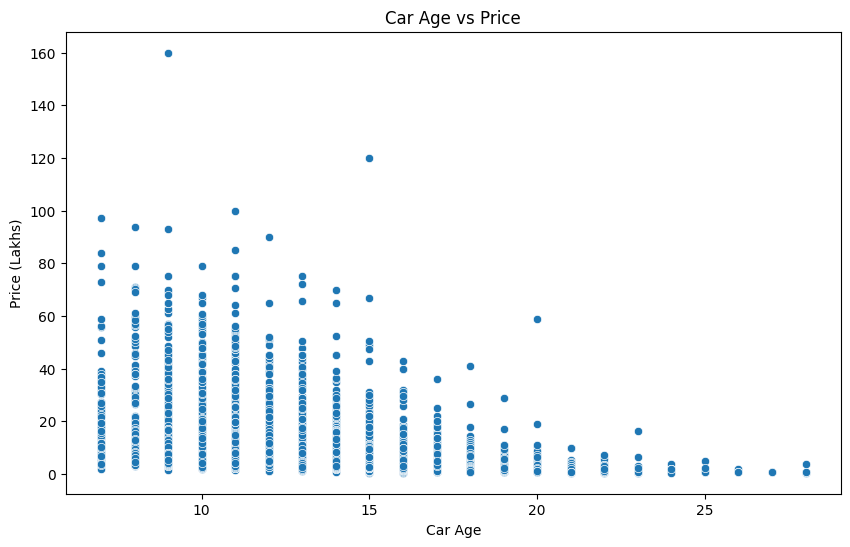

In [55]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Car_Age',
    y='Price'
)

plt.title('Car Age vs Price')
plt.xlabel('Car Age')
plt.ylabel('Price (Lakhs)')

plt.show()

In [56]:
# Average price of each brand

brand_price = (
    df.groupby('Brand')['Price']
    .mean()
    .sort_values(ascending=False)
)

print(brand_price)

Brand
Lamborghini      120.000000
Bentley           59.000000
Porsche           48.348333
Land              39.259500
Jaguar            37.632250
Mini              26.896923
Mercedes-Benz     26.809874
Audi              25.537712
BMW               25.243146
Isuzu             20.000000
Volvo             18.802857
Jeep              18.718667
ISUZU             12.045000
Toyota            11.580024
Mitsubishi        11.058889
Force              9.333333
Mahindra           8.045919
Skoda              7.559075
Ford               6.889400
Renault            5.799034
Honda              5.411743
Hyundai            5.343433
Volkswagen         5.307270
Nissan             4.738352
Maruti             4.517267
Tata               3.562849
Fiat               3.269286
Datsun             3.049231
Chevrolet          3.044463
Smart              3.000000
Ambassador         1.350000
Name: Price, dtype: float64


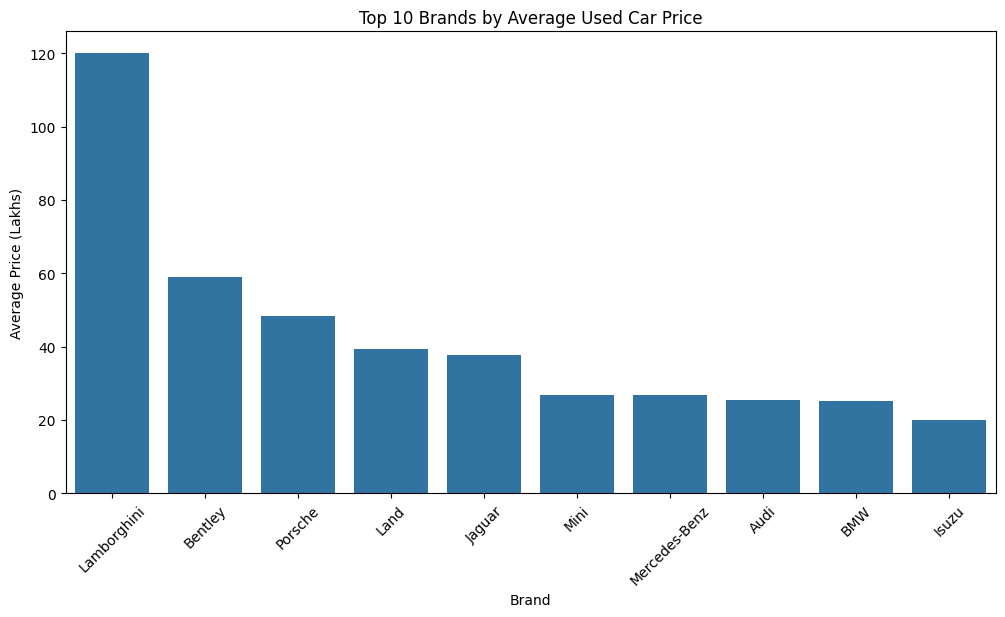

In [57]:
top_brands = brand_price.head(10)
plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)

plt.title('Top 10 Brands by Average Used Car Price')
plt.xlabel('Brand')
plt.ylabel('Average Price (Lakhs)')

plt.xticks(rotation=45)
plt.show()

In [58]:
# Select numerical columns
numerical_columns = [
    'Year',
    'Kilometers_Driven',
    'Mileage',
    'Engine',
    'Power',
    'Seats',
    'Car_Age',
    'Price'
]

# Calculate correlation
correlation = df[numerical_columns].corr()

# Display correlation values
print(correlation)

                       Year  Kilometers_Driven   Mileage    Engine     Power  \
Year               1.000000          -0.173048  0.321527 -0.046288  0.020247   
Kilometers_Driven -0.173048           1.000000 -0.065242  0.090476  0.032982   
Mileage            0.321527          -0.065242  1.000000 -0.581202 -0.520910   
Engine            -0.046288           0.090476 -0.581202  1.000000  0.866605   
Power              0.020247           0.032982 -0.520910  0.866605  1.000000   
Seats              0.015204           0.082782 -0.299600  0.393849  0.102948   
Car_Age           -1.000000           0.173048 -0.321527  0.046288 -0.020247   
Price              0.305327          -0.011493 -0.306610  0.657196  0.770992   

                      Seats   Car_Age     Price  
Year               0.015204 -1.000000  0.305327  
Kilometers_Driven  0.082782  0.173048 -0.011493  
Mileage           -0.299600 -0.321527 -0.306610  
Engine             0.393849  0.046288  0.657196  
Power              0.102948 -

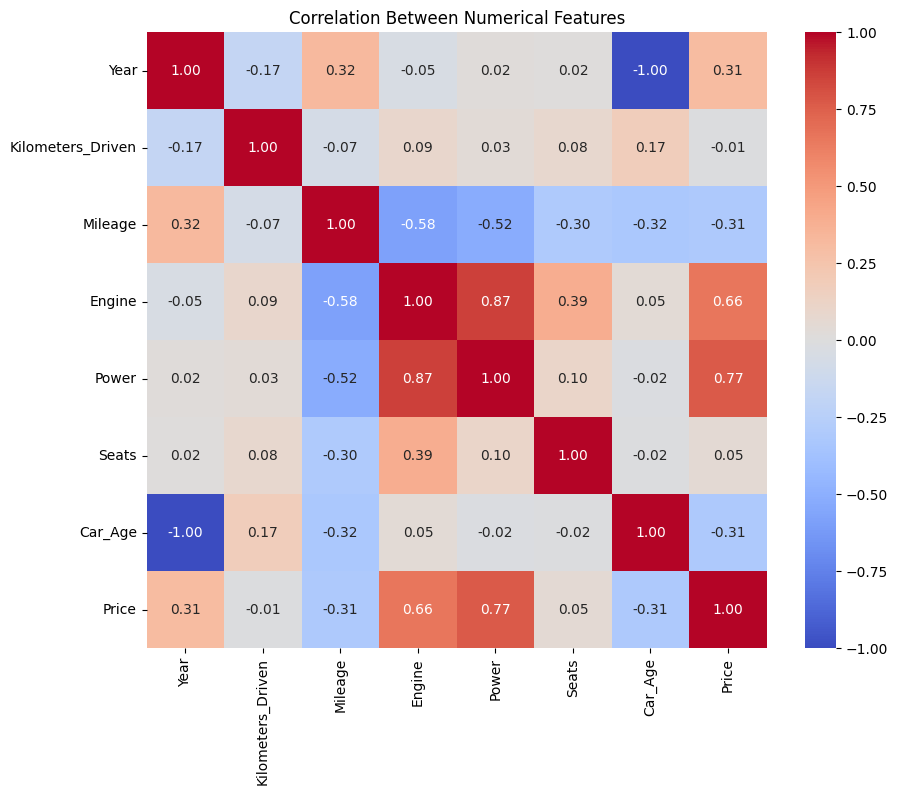

In [59]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Between Numerical Features')
plt.show()

In [60]:
# Average price according to fuel type

fuel_price = (
    df.groupby('Fuel_Type')['Price']
    .mean()
    .sort_values(ascending=False)
)

print(fuel_price)

Fuel_Type
Electric    12.875000
Diesel      12.840605
Petrol       5.701100
CNG          3.516786
LPG          2.487000
Name: Price, dtype: float64


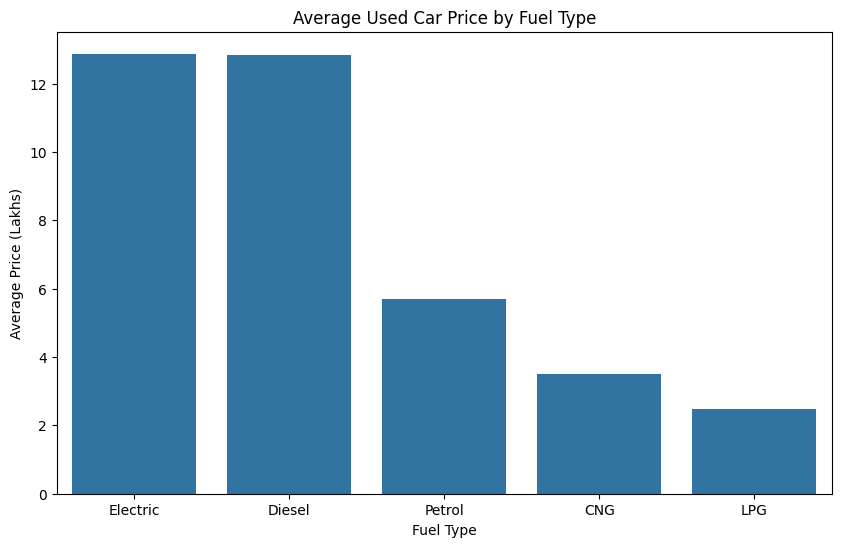

In [61]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=fuel_price.index,
    y=fuel_price.values
)

plt.title('Average Used Car Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Average Price (Lakhs)')

plt.show()

In [62]:
transmission_price = (
    df.groupby('Transmission')['Price']
    .mean()
    .sort_values(ascending=False)
)

print(transmission_price)

Transmission
Automatic    19.843971
Manual        5.332703
Name: Price, dtype: float64


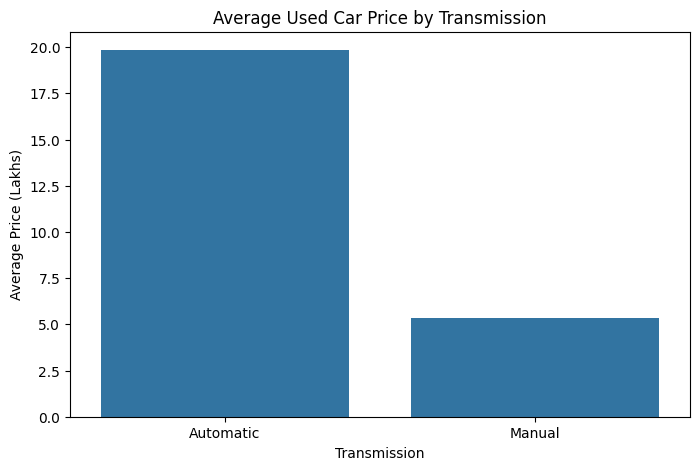

In [63]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=transmission_price.index,
    y=transmission_price.values
)

plt.title('Average Used Car Price by Transmission')
plt.xlabel('Transmission')
plt.ylabel('Average Price (Lakhs)')

plt.show()

In [64]:
print(df.columns.tolist())

['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Price', 'Car_Age', 'Brand']


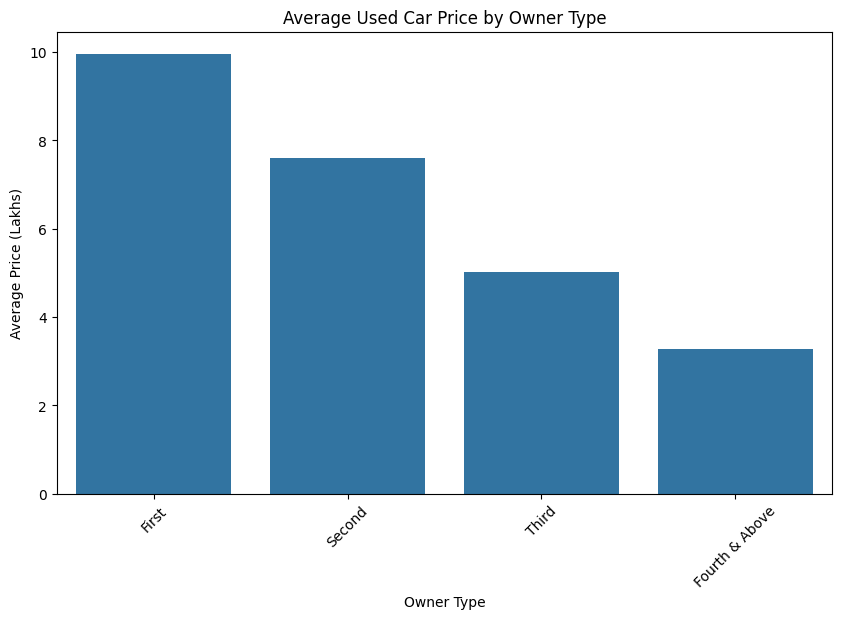

In [65]:
# Average used car price by Owner Type

owner_price = (
    df.groupby('Owner_Type')['Price']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=owner_price.index,
    y=owner_price.values
)

plt.title('Average Used Car Price by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Average Price (Lakhs)')

plt.xticks(rotation=45)
plt.show()

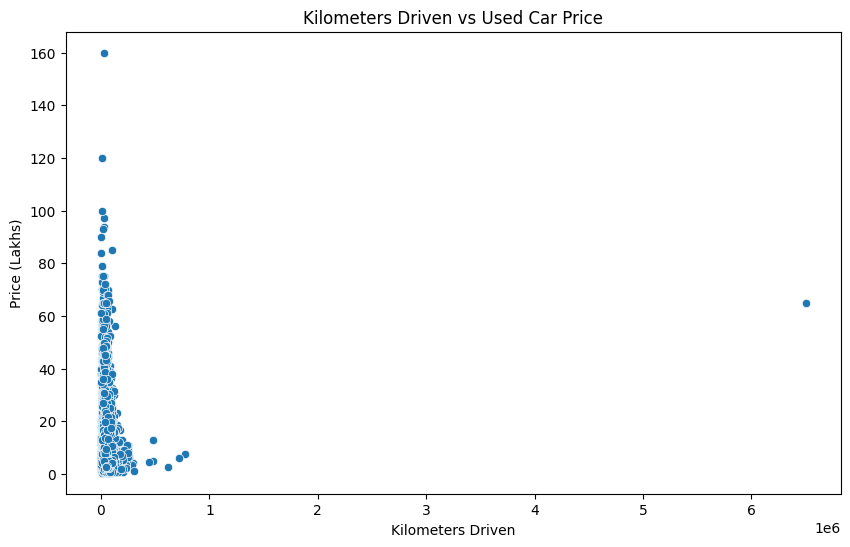

In [66]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Kilometers_Driven',
    y='Price'
)

plt.title('Kilometers Driven vs Used Car Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price (Lakhs)')

plt.show()

In [67]:
categorical_columns = df.select_dtypes(include='object').columns

print(categorical_columns)

Index(['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand'], dtype='str')


C:\Users\hp\AppData\Local\Temp\ipykernel_16188\3910604682.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


In [68]:
# Select categorical columns for encoding

columns_to_encode = [
    'Location',
    'Fuel_Type',
    'Transmission',
    'Owner_Type',
    'Brand'
]

# Convert categorical columns into numerical form
df_encoded = pd.get_dummies(
    df,
    columns=columns_to_encode,
    drop_first=True
)

print("Original dataset shape:", df.shape)
print("Encoded dataset shape:", df_encoded.shape)

df_encoded.head()

Original dataset shape: (6019, 14)
Encoded dataset shape: (6019, 57)


,Name,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Car_Age,Location_Bangalore,...,Brand_Mitsubishi,Brand_Nissan,Brand_Porsche,Brand_Renault,Brand_Skoda,Brand_Smart,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,Maruti Wagon R LXI CNG,2010,72000,26.60,998.0,58.16,5.0,1.75,16,False,...,False,False,False,False,False,False,False,False,False,False
1,Hyundai Creta 1.6 CRDi SX Option,2015,41000,19.67,1582.0,126.20,5.0,12.50,11,False,...,False,False,False,False,False,False,False,False,False,False
2,Honda Jazz V,2011,46000,18.20,1199.0,88.70,5.0,4.50,15,False,...,False,False,False,False,False,False,False,False,False,False
3,Maruti Ertiga VDI,2012,87000,20.77,1248.0,88.76,7.0,6.00,14,False,...,False,False,False,False,False,False,False,False,False,False
4,Audi A4 New 2.0 TDI Multitronic,2013,40670,15.20,1968.0,140.80,5.0,17.74,13,False,...,False,False,False,False,False,False,False,False,False,False


In [69]:
# Remove the Name column
df_model = df_encoded.drop('Name', axis=1)

# Separate features and target
X = df_model.drop('Price', axis=1)
y = df_model['Price']

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (6019, 55)
y shape: (6019,)


,Year,Kilometers_Driven,Mileage,Engine,Power,Seats,Car_Age,Location_Bangalore,Location_Chennai,Location_Coimbatore,...,Brand_Mitsubishi,Brand_Nissan,Brand_Porsche,Brand_Renault,Brand_Skoda,Brand_Smart,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Brand_Volvo
0,2010,72000,26.60,998.0,58.16,5.0,16,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2015,41000,19.67,1582.0,126.20,5.0,11,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2011,46000,18.20,1199.0,88.70,5.0,15,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2012,87000,20.77,1248.0,88.76,7.0,14,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,2013,40670,15.20,1968.0,140.80,5.0,13,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [70]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (4815, 55)
Testing data shape: (1204, 55)


In [71]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 81
Missing values in X_test: 26


In [72]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Missing values handled successfully!")

Missing values handled successfully!


In [73]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_imputed, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [74]:
y_pred = model.predict(X_test_imputed)

print("Predictions generated successfully!")
print(y_pred[:10])

Predictions generated successfully!
[ 5.68933279 10.98332298  8.7954362   4.19604971  0.75638276  7.98946902
  6.87598755  4.20924357 12.74559878  4.81624009]


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 3.1453384750741593
MSE: 52.99403287223902
RMSE: 7.279700053727421
R² Score: 0.5693624924258818


In [76]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_imputed, y_train)

print("Random Forest model training completed successfully!")

Random Forest model training completed successfully!


In [77]:
rf_pred = rf_model.predict(X_test_imputed)

print("Random Forest Predictions generated successfully!")
print(rf_pred[:10])

Random Forest Predictions generated successfully!
[ 5.8407 12.878   8.0062  2.287   2.3542  3.9453  5.3628  4.0425 14.2812
  4.4668]


In [78]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results:")
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results:
MAE: 1.4913946005378895
MSE: 13.211175030376657
RMSE: 3.6347180124978964
R² Score: 0.8926439982229181


In [79]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, rf_mae],
    'MSE': [mse, rf_mse],
    'RMSE': [rmse, rf_rmse],
    'R2 Score': [r2, rf_r2]
})

comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,3.145338,52.994033,7.279700,0.569362
1,Random Forest,1.491395,13.211175,3.634718,0.892644


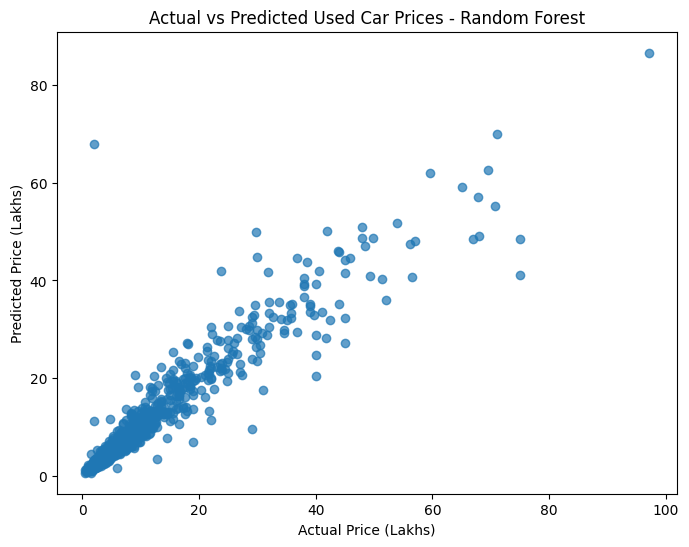

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_pred, alpha=0.7)

plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted Used Car Prices - Random Forest")

plt.show()

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                Feature  Importance
4                 Power    0.654720
6               Car_Age    0.087290
0                  Year    0.067546
1     Kilometers_Driven    0.045351
3                Engine    0.038972
40           Brand_Land    0.024743
2               Mileage    0.018511
5                 Seats    0.008784
11   Location_Hyderabad    0.008120
21  Transmission_Manual    0.006547


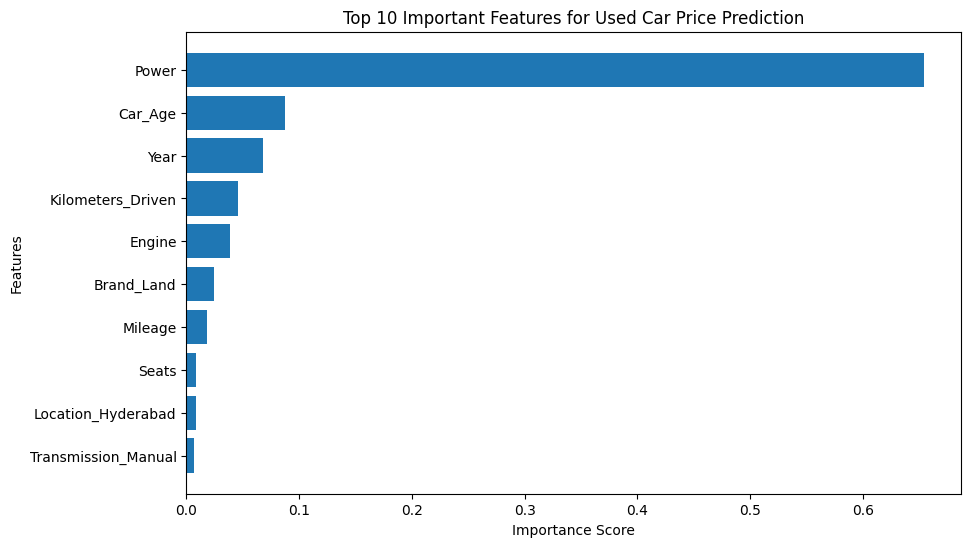

In [82]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features for Used Car Price Prediction")

plt.gca().invert_yaxis()
plt.show()

In [83]:
import joblib

joblib.dump(rf_model, "random_forest_model.pkl")

['random_forest_model.pkl']

In [84]:
joblib.dump(imputer, "imputer.pkl")

['imputer.pkl']

In [85]:
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [88]:
import joblib

feature_names = joblib.load("feature_names.pkl")

print(feature_names)

['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age', 'Location_Bangalore', 'Location_Chennai', 'Location_Coimbatore', 'Location_Delhi', 'Location_Hyderabad', 'Location_Jaipur', 'Location_Kochi', 'Location_Kolkata', 'Location_Mumbai', 'Location_Pune', 'Fuel_Type_Diesel', 'Fuel_Type_Electric', 'Fuel_Type_LPG', 'Fuel_Type_Petrol', 'Transmission_Manual', 'Owner_Type_Fourth & Above', 'Owner_Type_Second', 'Owner_Type_Third', 'Brand_Audi', 'Brand_BMW', 'Brand_Bentley', 'Brand_Chevrolet', 'Brand_Datsun', 'Brand_Fiat', 'Brand_Force', 'Brand_Ford', 'Brand_Honda', 'Brand_Hyundai', 'Brand_ISUZU', 'Brand_Isuzu', 'Brand_Jaguar', 'Brand_Jeep', 'Brand_Lamborghini', 'Brand_Land', 'Brand_Mahindra', 'Brand_Maruti', 'Brand_Mercedes-Benz', 'Brand_Mini', 'Brand_Mitsubishi', 'Brand_Nissan', 'Brand_Porsche', 'Brand_Renault', 'Brand_Skoda', 'Brand_Smart', 'Brand_Tata', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Volvo']
